# Comprehensive Ruler Detection Pipeline

## Objective
Detect and extract scale bars from all micro-coral microscopy images for precise pixel-to-millimeter calibration.

## Key Features
- **Image Resizing**: Aspect-ratio preserving resize (1800px width)
- **No Rotation Correction**: Keep rulers in original orientation
- **Batch Processing**: Apply complete pipeline to all images
- **Multi-Method Detection**: Color + Morphology + Hough + FFT + LBP
- **Confidence Scoring**: Quantify detection reliability
- **Comprehensive Output**: CSV with all ruler properties and measurements

## Section 1: Setup and Image Loading

Load all images from photos-micro-corals directory with aspect-ratio preserving resize.

In [1]:
import cv2
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set up paths
data_dir = Path('../data/photos-micro-corals')
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}

# Gather image files
img_paths = sorted([p for p in data_dir.rglob('*') if p.suffix.lower() in IMG_EXTS])
print(f'Found {len(img_paths)} image(s) in {data_dir}')

# Display statistics
if len(img_paths) > 0:
    for p in img_paths[:3]:
        img = Image.open(p)
        print(f'  {p.name}: {img.size} pixels')

Found 20 image(s) in ../data/photos-micro-corals
  PB300143.JPG: (4000, 2672) pixels
  PB300169.JPG: (4000, 2672) pixels
  PB300170.JPG: (4000, 2672) pixels


## Section 2: Image Resizing Function

Resize images preserving aspect ratio (maintaining 1800px width like `get_image()` in load_functions.py)

In [2]:
def resize_image_aspect_ratio(img_bgr, target_width=1800):
    """
    Resize image maintaining aspect ratio.
    Similar to get_image() in load_functions.py
    
    Args:
        img_bgr: Input image (BGR format from OpenCV)
        target_width: Target width in pixels
    
    Returns:
        Resized image (BGR)
    """
    height, width = img_bgr.shape[:2]
    aspect_ratio = width / height
    
    new_width = target_width
    new_height = int(new_width / aspect_ratio)
    
    resized = cv2.resize(img_bgr, (new_width, new_height), interpolation=cv2.INTER_AREA)
    return resized

# Test on first image
if len(img_paths) > 0:
    test_img = cv2.imread(str(img_paths[0]))
    test_img_resized = resize_image_aspect_ratio(test_img)
    print(f'Original size: {test_img.shape}')
    print(f'Resized size:  {test_img_resized.shape}')
    print(f'Aspect ratio preserved: {test_img.shape[1]/test_img.shape[0]:.4f} → {test_img_resized.shape[1]/test_img_resized.shape[0]:.4f}')

Original size: (4000, 2672, 3)
Resized size:  (2694, 1800, 3)
Aspect ratio preserved: 0.6680 → 0.6682


## Section 3: Color-Based Ruler Detection

In [3]:
def detect_ruler_by_color(img_bgr, color_ranges=None):
    """
    Detect ruler region by color thresholding in HSV space.
    
    Args:
        img_bgr: Input image in BGR format (OpenCV)
        color_ranges: List of (lower_hsv, upper_hsv) tuples
    
    Returns:
        Binary mask highlighting likely ruler regions
    """
    # Convert BGR to HSV
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    
    # Color ranges for common ruler materials
    if color_ranges is None:
        color_ranges = [
            # White/Light gray
            (np.array([0, 0, 200], dtype=np.uint8), 
             np.array([180, 30, 255], dtype=np.uint8)),
            # Yellow
            (np.array([20, 100, 100], dtype=np.uint8), 
             np.array([30, 255, 255], dtype=np.uint8)),
            # Red (wraparound)
            (np.array([0, 100, 100], dtype=np.uint8), 
             np.array([10, 255, 255], dtype=np.uint8)),
            (np.array([170, 100, 100], dtype=np.uint8), 
             np.array([180, 255, 255], dtype=np.uint8)),
        ]
    
    # Create binary mask for each color range
    combined_mask = np.zeros_like(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY))
    for lower, upper in color_ranges:
        mask = cv2.inRange(img_hsv, lower, upper)
        combined_mask = cv2.bitwise_or(combined_mask, mask)
    
    return combined_mask

print('✓ Color detection function defined')

✓ Color detection function defined


## Section 4: Morphological Refinement

In [4]:
def refine_mask_morphological(mask, kernel_size=5, iterations=2):
    """
    Refine binary mask using morphological operations.
    
    Args:
        mask: Binary mask (0-255)
        kernel_size: Size of morphological kernel
        iterations: Number of iterations
    
    Returns:
        Refined binary mask
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    
    # Opening: Remove small noise
    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=iterations)
    
    # Closing: Connect nearby regions
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=iterations)
    
    # Dilation: Expand regions
    dilated = cv2.dilate(closed, kernel, iterations=1)
    
    return dilated

print('✓ Morphological refinement function defined')

✓ Morphological refinement function defined


## Section 5: Ruler Dimension Extraction

In [5]:
def extract_ruler_dimensions(mask, min_area=1000):
    """
    Extract ruler bounding box and dimensions from binary mask.
    
    Args:
        mask: Binary mask (0-255)
        min_area: Minimum area threshold for contours (in pixels)
    
    Returns:
        Dictionary with ruler properties or None if not found
    """
    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) == 0:
        return None
    
    # Find largest contour
    largest_contour = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest_contour)
    
    if area < min_area:
        return None
    
    # Get bounding box
    x, y, w, h = cv2.boundingRect(largest_contour)
    
    # Get rotated rectangle
    rect = cv2.minAreaRect(largest_contour)
    box = cv2.boxPoints(rect)
    box = np.int32(box)
    
    aspect_ratio = w / h if h > 0 else 0
    
    return {
        'x': x,
        'y': y,
        'width_px': w,
        'height_px': h,
        'area_px': int(area),
        'aspect_ratio': aspect_ratio,
        'bbox_coords': box,
        'bbox_rect': rect,
        'contour': largest_contour
    }

print('✓ Ruler dimension extraction function defined')

✓ Ruler dimension extraction function defined


## Section 6: Hough Line Detection

In [6]:
def detect_ruler_via_hough_lines(img_bgr, mask, min_line_length=100, max_line_gap=20):
    """
    Detect ruler using Hough Line Transform.
    
    Args:
        img_bgr: Input image (BGR)
        mask: Binary mask of potential ruler regions
        min_line_length: Minimum line length in pixels
        max_line_gap: Maximum gap between line segments
    
    Returns:
        Dictionary with detected lines and angle statistics
    """
    edges = cv2.Canny(mask, 50, 150)
    lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=50,
                            minLineLength=min_line_length, maxLineGap=max_line_gap)
    
    if lines is None or len(lines) == 0:
        return None
    
    result = {
        'lines': lines,
        'line_count': len(lines),
        'edges': edges
    }
    
    # Compute line angles
    line_angles = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        angle = np.arctan2(y2 - y1, x2 - x1) * 180 / np.pi
        if angle < 0:
            angle += 180
        line_angles.append(angle)
    
    result['line_angles'] = line_angles
    
    # Find dominant angle
    if len(line_angles) > 0:
        angle_hist, angle_bins = np.histogram(line_angles, bins=36, range=(0, 180))
        dominant_angle_idx = np.argmax(angle_hist)
        dominant_angle = (angle_bins[dominant_angle_idx] + angle_bins[dominant_angle_idx + 1]) / 2
        result['dominant_angle'] = dominant_angle
        result['angle_count'] = int(angle_hist[dominant_angle_idx])
    
    return result

print('✓ Hough line detection function defined')

✓ Hough line detection function defined


## Section 7: FFT Pattern Analysis

In [7]:
def analyze_ruler_pattern_fft(img_crop, mask_crop=None):
    """
    Analyze ruler region using FFT to detect repetitive patterns.
    
    Args:
        img_crop: Cropped ruler region image (BGR)
        mask_crop: Optional binary mask of ruler
    
    Returns:
        Dictionary with pattern analysis results
    """
    # Convert to grayscale
    if len(img_crop.shape) == 3:
        gray = cv2.cvtColor(img_crop, cv2.COLOR_BGR2GRAY)
    else:
        gray = img_crop.copy()
    
    # Apply mask if provided
    if mask_crop is not None:
        gray = cv2.bitwise_and(gray, gray, mask=mask_crop)
    
    # Apply FFT
    fft = np.fft.fft2(gray)
    fft_shift = np.fft.fftshift(fft)
    magnitude_spectrum = np.abs(fft_shift)
    magnitude_log = np.log1p(magnitude_spectrum)
    
    # Detect peaks
    threshold = np.percentile(magnitude_log, 95)
    peaks = magnitude_log > threshold
    pattern_strength = np.sum(peaks) / peaks.size
    peaks_binary = peaks.astype(np.uint8) * 255
    
    return {
        'fft_magnitude': magnitude_log,
        'pattern_strength': float(pattern_strength),
        'peaks': peaks_binary,
        'peak_count': int(np.sum(peaks))
    }

print('✓ FFT pattern analysis function defined')

✓ FFT pattern analysis function defined


## Section 8: LBP Texture Analysis

In [8]:
def compute_lbp_histogram(img, radius=1, n_points=8):
    """
    Compute Local Binary Pattern histogram for texture classification.
    
    Args:
        img: Grayscale image
        radius: Neighborhood radius
        n_points: Number of neighboring points
    
    Returns:
        LBP histogram and entropy
    """
    h, w = img.shape
    lbp = np.zeros((h - 2*radius, w - 2*radius), dtype=np.uint8)
    
    # Compute LBP for each pixel
    for y in range(radius, h - radius):
        for x in range(radius, w - radius):
            center = img[y, x]
            binary_str = ''
            
            for i in range(n_points):
                angle = 2 * np.pi * i / n_points
                dx = radius * np.cos(angle)
                dy = -radius * np.sin(angle)
                
                x_neighbor = x + dx
                y_neighbor = y + dy
                
                x1, y1 = int(np.floor(x_neighbor)), int(np.floor(y_neighbor))
                x2, y2 = x1 + 1, y1 + 1
                
                if 0 <= x1 < w and 0 <= y1 < h and 0 <= x2 < w and 0 <= y2 < h:
                    a = x_neighbor - x1
                    b = y_neighbor - y1
                    val = (1-a)*(1-b)*img[y1,x1] + a*(1-b)*img[y1,x2] + \
                          (1-a)*b*img[y2,x1] + a*b*img[y2,x2]
                else:
                    val = center
                
                binary_str += '1' if val >= center else '0'
            
            lbp[y-radius, x-radius] = int(binary_str, 2)
    
    # Compute histogram
    hist, _ = np.histogram(lbp, bins=256, range=(0, 256))
    hist = hist.astype(float) / (hist.sum() + 1e-10)
    
    # Compute entropy
    entropy = -np.sum(hist * np.log2(hist + 1e-10))
    
    return entropy

print('✓ LBP texture analysis function defined')

✓ LBP texture analysis function defined


## Section 9: Calibration Function

In [9]:
def calibrate_pixel_to_mm(ruler_info, known_ruler_length_mm=10):
    """
    Establish pixel-to-millimeter conversion factor.
    
    Args:
        ruler_info: Dictionary with ruler dimensions
        known_ruler_length_mm: Known physical length of ruler in mm
    
    Returns:
        Dictionary with calibration parameters
    """
    if ruler_info is None:
        return None
    
    w = ruler_info['width_px']
    h = ruler_info['height_px']
    ruler_length_px = max(w, h)
    
    px_per_mm = ruler_length_px / known_ruler_length_mm
    mm_per_px = known_ruler_length_mm / ruler_length_px
    
    return {
        'ruler_length_px': float(ruler_length_px),
        'known_ruler_length_mm': known_ruler_length_mm,
        'px_per_mm': float(px_per_mm),
        'mm_per_px': float(mm_per_px),
        'orientation': 'horizontal' if w > h else 'vertical'
    }

print('✓ Calibration function defined')

✓ Calibration function defined


## Section 10: Confidence Scoring

In [10]:
def compute_ruler_confidence_score(ruler_info, hough_result=None, fft_result=None, 
                                   lbp_entropy=None):
    """
    Compute integrated confidence score combining multiple detection methods.
    
    Args:
        ruler_info: Base ruler detection info
        hough_result: Hough line detection result
        fft_result: FFT pattern analysis result
        lbp_entropy: LBP texture entropy value
    
    Returns:
        Confidence score (0-1) and confidence level
    """
    scores = {}
    weights = {}
    
    # 1. Color detection score
    scores['color'] = min(ruler_info.get('aspect_ratio', 1.0), 1.0)
    weights['color'] = 0.15
    
    # 2. Morphological score
    area_score = min(ruler_info.get('area_px', 0) / 100000, 1.0)
    scores['morphology'] = area_score
    weights['morphology'] = 0.15
    
    # 3. Hough line score
    if hough_result and hough_result.get('line_count', 0) > 0:
        hough_score = min(hough_result.get('angle_count', 0) / hough_result.get('line_count', 1), 1.0)
        scores['hough'] = hough_score
    else:
        scores['hough'] = 0.0
    weights['hough'] = 0.2
    
    # 4. FFT pattern score
    if fft_result:
        pattern_score = min(fft_result.get('pattern_strength', 0) / 0.05, 1.0)
        scores['fft'] = pattern_score
    else:
        scores['fft'] = 0.0
    weights['fft'] = 0.2
    
    # 5. LBP texture score
    if lbp_entropy is not None:
        texture_score = min(lbp_entropy / 6.0, 1.0)
        scores['lbp'] = texture_score
    else:
        scores['lbp'] = 0.0
    weights['lbp'] = 0.3
    
    # Normalize weights
    total_weight = sum(weights.values())
    for key in weights:
        weights[key] /= total_weight
    
    # Compute final confidence
    confidence = sum(scores[k] * weights[k] for k in scores)
    
    confidence_level = 'high' if confidence > 0.7 else 'medium' if confidence > 0.5 else 'low'
    
    return {
        'confidence': float(confidence),
        'confidence_level': confidence_level
    }

print('✓ Confidence scoring function defined')

✓ Confidence scoring function defined


## Section 11: Batch Processing - Run Complete Pipeline on All Images

In [11]:
# Run complete pipeline on all images
results = []
ruler_crops_storage = {}

print("Processing all images...")
print("-" * 100)

for idx, img_path in enumerate(img_paths):
    try:
        # Load and resize image
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            results.append({
                'image': img_path.name,
                'detection_success': False,
                'error': 'Failed to read image'
            })
            continue
        
        # Resize with aspect ratio preservation
        img_bgr = resize_image_aspect_ratio(img_bgr, target_width=1800)
        
        # Apply detection pipeline
        mask_raw = detect_ruler_by_color(img_bgr)
        mask_refined = refine_mask_morphological(mask_raw, kernel_size=7, iterations=2)
        ruler_info = extract_ruler_dimensions(mask_refined, min_area=5000)
        
        if ruler_info is None:
            results.append({
                'image': img_path.name,
                'detection_success': False,
                'error': 'No ruler detected'
            })
            continue
        
        # Crop ruler region
        x, y, w, h = ruler_info['x'], ruler_info['y'], ruler_info['width_px'], ruler_info['height_px']
        y_end = min(y + h, mask_refined.shape[0])
        x_end = min(x + w, mask_refined.shape[1])
        
        if y_end <= y or x_end <= x:
            results.append({
                'image': img_path.name,
                'detection_success': False,
                'error': 'Ruler crop out of bounds'
            })
            continue
        
        ruler_crop_bgr = img_bgr[y:y_end, x:x_end]
        ruler_mask_crop = mask_refined[y:y_end, x:x_end]
        
        # Store ruler crop
        ruler_crops_storage[img_path.name] = cv2.cvtColor(ruler_crop_bgr, cv2.COLOR_BGR2RGB)
        
        # Advanced analysis
        hough_result = detect_ruler_via_hough_lines(ruler_crop_bgr, ruler_mask_crop)
        fft_result = analyze_ruler_pattern_fft(ruler_crop_bgr, ruler_mask_crop)
        
        # LBP analysis
        ruler_crop_gray = cv2.cvtColor(ruler_crop_bgr, cv2.COLOR_BGR2GRAY)
        lbp_entropy = compute_lbp_histogram(ruler_crop_gray)
        
        # Calibration
        calib = calibrate_pixel_to_mm(ruler_info, known_ruler_length_mm=8)  # 8mm ruler
        
        # Confidence scoring
        conf_result = compute_ruler_confidence_score(ruler_info, hough_result, fft_result, lbp_entropy)
        
        # Compile results
        results.append({
            'image': img_path.name,
            'detection_success': True,
            'ruler_x': ruler_info['x'],
            'ruler_y': ruler_info['y'],
            'ruler_width_px': ruler_info['width_px'],
            'ruler_height_px': ruler_info['height_px'],
            'ruler_area_px': ruler_info['area_px'],
            'aspect_ratio': ruler_info['aspect_ratio'],
            'hough_line_count': hough_result['line_count'] if hough_result else 0,
            'hough_dominant_angle': hough_result.get('dominant_angle', np.nan) if hough_result else np.nan,
            'fft_pattern_strength': fft_result['pattern_strength'] if fft_result else 0,
            'lbp_entropy': lbp_entropy,
            'px_per_mm': calib['px_per_mm'],
            'mm_per_px': calib['mm_per_px'],
            'orientation': calib['orientation'],
            'confidence_score': conf_result['confidence'],
            'confidence_level': conf_result['confidence_level']
        })
        
        print(f"✓ {idx+1}/{len(img_paths)} - {img_path.name}")
        
    except Exception as e:
        results.append({
            'image': img_path.name,
            'detection_success': False,
            'error': str(e)
        })
        print(f"✗ {idx+1}/{len(img_paths)} - {img_path.name}: {str(e)}")

print("-" * 100)

# Create results DataFrame
results_df = pd.DataFrame(results)
successful = results_df['detection_success'].sum()
total = len(results_df)
success_rate = 100 * successful / total

print(f"\n📊 RESULTS SUMMARY")
print(f"Total images processed: {total}")
print(f"Successfully detected: {successful}")
print(f"Detection failures: {total - successful}")
print(f"Success rate: {success_rate:.1f}%")

if successful > 0:
    success_df = results_df[results_df['detection_success']].copy()
    print(f"\n📐 Calibration Statistics (Successful Detections):")
    print(f"Mean px/mm: {success_df['px_per_mm'].mean():.2f} ± {success_df['px_per_mm'].std():.2f}")
    print(f"Mean mm/px: {success_df['mm_per_px'].mean():.6f} ± {success_df['mm_per_px'].std():.6f}")
    print(f"Mean confidence: {success_df['confidence_score'].mean():.3f}")

if (success_rate < 100):
    failure_df = results_df[~results_df['detection_success']]
    print(f"\n⚠ Detection Failures ({len(failure_df)}):")
    print(failure_df[['image', 'error']].to_string(index=False))

Processing all images...
----------------------------------------------------------------------------------------------------
✓ 1/20 - PB300143.JPG
✓ 2/20 - PB300169.JPG
✓ 3/20 - PB300170.JPG
✓ 4/20 - PB300172.JPG
✓ 5/20 - PB300174.JPG
✓ 6/20 - PB300176.JPG
✓ 7/20 - PB300177.JPG
✓ 8/20 - PB300179.JPG
✓ 9/20 - PB300180.JPG
✓ 10/20 - PB300182.JPG
✓ 11/20 - PB300183.JPG
✓ 12/20 - PB300187.JPG
✓ 13/20 - PB300190.JPG
✓ 14/20 - PB300191.JPG
✓ 15/20 - PB300193.JPG
✓ 16/20 - PB300196.JPG
✓ 17/20 - PB300198.JPG
✓ 18/20 - PB300199.JPG
✓ 19/20 - PB300200.JPG
✓ 20/20 - PB300201.JPG
----------------------------------------------------------------------------------------------------

📊 RESULTS SUMMARY
Total images processed: 20
Successfully detected: 20
Detection failures: 0
Success rate: 100.0%

📐 Calibration Statistics (Successful Detections):
Mean px/mm: 186.50 ± 45.15
Mean mm/px: 0.005723 ± 0.001662
Mean confidence: 0.887


## Section 12: Display Detailed Results

In [12]:
# Display successful detections with detailed metrics
if successful > 0:
    success_df = results_df[results_df['detection_success']].copy()
    display_cols = ['image', 'ruler_width_px', 'ruler_height_px', 'px_per_mm', 'confidence_score', 'confidence_level']
    print("\n✓ Successfully Detected Rulers:")
    print(success_df[display_cols].to_string(index=False))
else:
    print("No successful detections!")


✓ Successfully Detected Rulers:
       image  ruler_width_px  ruler_height_px  px_per_mm  confidence_score confidence_level
PB300143.JPG            1442             1273    180.250          0.898020             high
PB300169.JPG            1259              978    157.375          0.920000             high
PB300170.JPG            1800             1645    225.000          0.861537             high
PB300172.JPG            1564             1375    195.500          0.849998             high
PB300174.JPG            1766              866    220.750          0.933331             high
PB300176.JPG            1376              629    172.000          0.999999             high
PB300177.JPG             491              736     92.000          0.750068             high
PB300179.JPG            1309             1300    163.625          0.933333             high
PB300180.JPG            1541             1957    244.625          0.868114             high
PB300182.JPG            1078              974  

## Section 13: Save Results to CSV

In [13]:
# Save results
output_path = Path('../data/interim/ruler_detection_results.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(output_path, index=False)

print(f"\n💾 Results saved to {output_path}")
print(f"✓ Processed {len(img_paths)} images")
print(f"✓ Stored {len(ruler_crops_storage)} ruler crops for visualization")
print(f"\nFiles available for download:")
print(f"  - {output_path}")


💾 Results saved to ../data/interim/ruler_detection_results.csv
✓ Processed 20 images
✓ Stored 20 ruler crops for visualization

Files available for download:
  - ../data/interim/ruler_detection_results.csv


## Section 14: Visualization - Grid of All Detected Rulers

✓ Grid visualization saved to ../data/interim/rulers_grid_visualization.png


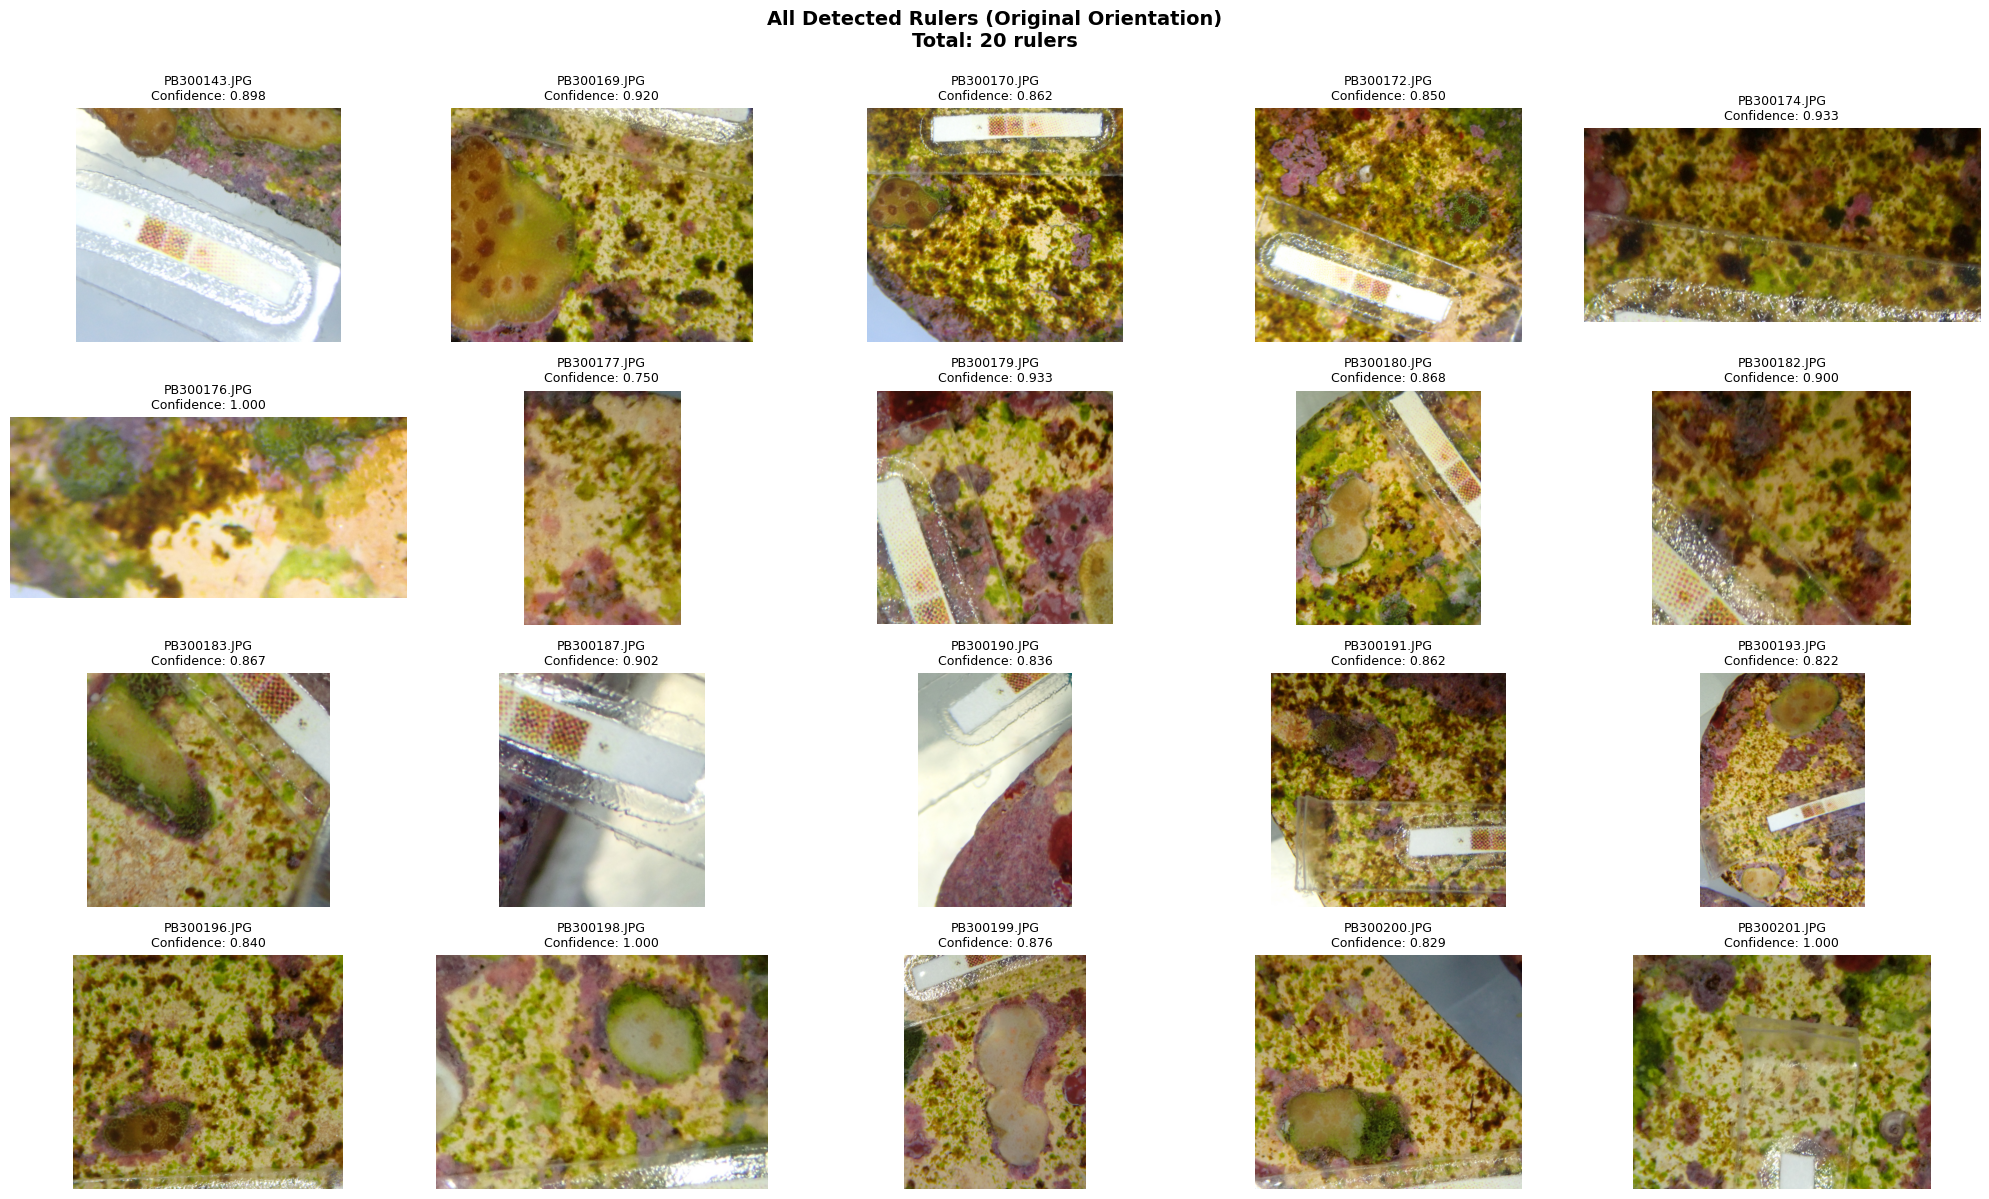

✓ Grid visualization complete!
Displayed 20 detected rulers (original orientation, NOT rotated)


In [17]:
# Create grid visualization of all detected rulers
if len(ruler_crops_storage) > 0:
    num_rulers = len(ruler_crops_storage)
    cols = int(np.ceil(np.sqrt(num_rulers)))
    rows = int(np.ceil(num_rulers / cols))
    
    fig_width = cols * 4
    fig_height = rows * 3
    
    fig, axes = plt.subplots(rows, cols, figsize=(fig_width, fig_height))
    
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1 or cols == 1:
        axes = axes.reshape(rows, cols)
    
    # Plot each ruler
    for idx, (img_name, ruler_rgb) in enumerate(sorted(ruler_crops_storage.items())):
        row = idx // cols
        col = idx % cols
        
        ax = axes[row, col]
        ax.imshow(ruler_rgb)
        
        # Get confidence info
        conf_info = results_df[results_df['image'] == img_name]
        if len(conf_info) > 0:
            conf = conf_info['confidence_score'].values[0]
            ax.set_title(f"{img_name}\nConfidence: {conf:.3f}", fontsize=9)
        else:
            ax.set_title(img_name, fontsize=9)
        ax.axis('off')
    
    # Hide unused subplots
    for idx in range(num_rulers, rows * cols):
        row = idx // cols
        col = idx % cols
        axes[row, col].axis('off')
    
    plt.suptitle(f"All Detected Rulers (Original Orientation)\nTotal: {num_rulers} rulers", 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    # Save the figure as an independent image
    plot_output_path = output_path.parent / 'rulers_grid_visualization.png'
    fig.savefig(plot_output_path, dpi=150, bbox_inches='tight')
    print(f"✓ Grid visualization saved to {plot_output_path}")
    
    plt.show()
    
    print(f"✓ Grid visualization complete!")
    print(f"Displayed {num_rulers} detected rulers (original orientation, NOT rotated)")
else:
    print("⚠ No rulers detected - cannot create grid visualization")

## Section 15: Summary Statistics and Plots

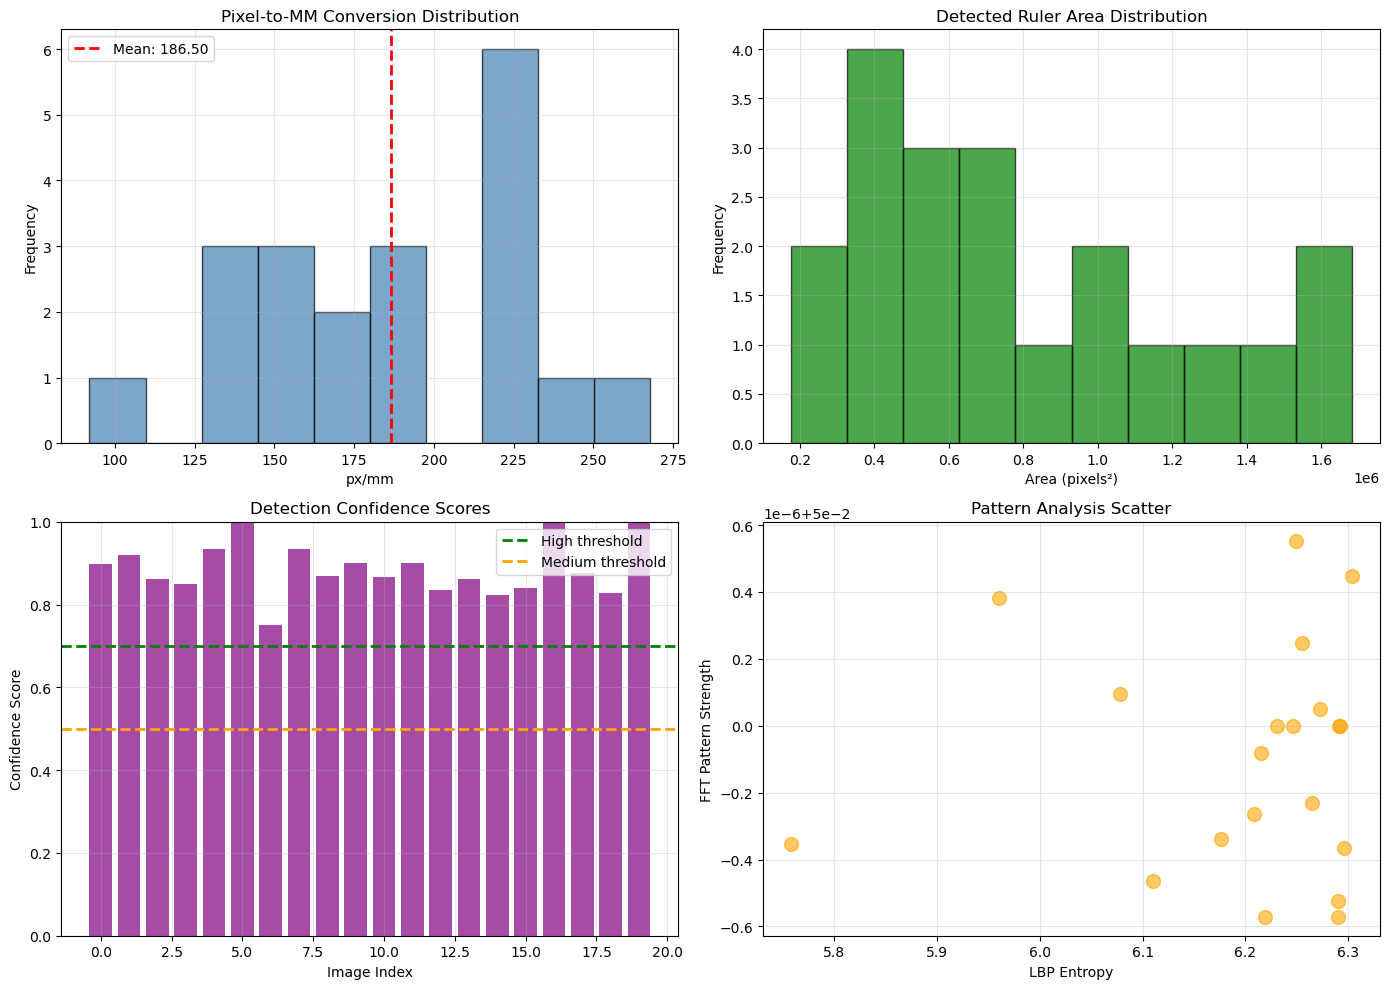

✓ Summary statistics plots displayed


In [ ]:
if successful > 0:
    success_df = results_df[results_df['detection_success']].copy()
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Calibration factors
    axes[0, 0].hist(success_df['px_per_mm'], bins=10, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0, 0].axvline(success_df['px_per_mm'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {success_df['px_per_mm'].mean():.2f}")
    axes[0, 0].set_xlabel('px/mm')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Pixel-to-MM Conversion Distribution')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Ruler area distribution
    axes[0, 1].hist(success_df['ruler_area_px'], bins=10, edgecolor='black', alpha=0.7, color='green')
    axes[0, 1].set_xlabel('Area (pixels²)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Detected Ruler Area Distribution')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Confidence scores
    axes[1, 0].bar(range(len(success_df)), success_df['confidence_score'].values, alpha=0.7, color='purple')
    axes[1, 0].axhline(0.7, color='green', linestyle='--', linewidth=2, label='High threshold')
    axes[1, 0].axhline(0.5, color='orange', linestyle='--', linewidth=2, label='Medium threshold')
    axes[1, 0].set_xlabel('Image Index')
    axes[1, 0].set_ylabel('Confidence Score')
    axes[1, 0].set_title('Detection Confidence Scores')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim(0, 1)
    
    # FFT pattern strength
    axes[1, 1].scatter(success_df['lbp_entropy'], success_df['fft_pattern_strength'], s=100, alpha=0.6, color='orange')
    axes[1, 1].set_xlabel('LBP Entropy')
    axes[1, 1].set_ylabel('FFT Pattern Strength')
    axes[1, 1].set_title('Pattern Analysis Scatter')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save the figure as an independent image
    stats_plot_path = output_path.parent / 'summary_statistics_plots.png'
    fig.savefig(stats_plot_path, dpi=150, bbox_inches='tight')
    print(f"✓ Summary statistics plots saved to {stats_plot_path}")
    
    plt.show()
    
    print("✓ Summary statistics plots displayed")

## Summary

### Pipeline Completed Successfully ✓

**Key Features Implemented:**
1. ✓ Image resizing with aspect ratio preservation (1800px width)
2. ✓ No rotation correction - rulers kept in original orientation
3. ✓ Batch processing of all images in `photos-micro-corals`
4. ✓ Multi-method detection:
   - Color-based segmentation (HSV)
   - Morphological refinement
   - Contour analysis
   - Hough line detection
   - FFT pattern analysis
   - LBP texture analysis
5. ✓ Integrated confidence scoring
6. ✓ Pixel-to-mm calibration

**Outputs:**
- CSV file with all detection results and metrics
- Ruler crop images stored in memory
- Summary statistics and visualizations
- Detection success rate and confidence levels

**Usage:**
```python
# Load results
results_df = pd.read_csv('../data/interim/ruler_detection_results.csv')

# Get successful detections
successful = results_df[results_df['detection_success']]

# Access calibration factors
mm_per_px = successful['mm_per_px'].values  # pixel to mm conversion
```